# 02 - KPI calculation and exploratory maps (CDMX Urban Intelligence)

**Purpose.** Show that every required KPI can be computed from the PostgreSQL/PostGIS warehouse alone, and
explore how demographic, economic and public-safety indicators are distributed across Mexico City.

**Rule followed.** All numbers below come from SQL queries against the `dw` schema (facts, dimensions and the
`dw.vw_ageb_kpis` view). No raw file, CSV or intermediate DataFrame is used.

**Unit of analysis.** Urban AGEB (INEGI basic geostatistical area), 2,431 units covering the 16 alcaldias.
Population is from Census 2020; businesses are DENUE 11/2024; crime is FGJ 2024 (incident date).

In [1]:
import sys, warnings
from pathlib import Path

# make the project's src/ package importable when the notebook runs from notebooks/
SRC = Path.cwd().resolve().parent / "src"
sys.path.insert(0, str(SRC))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import config
import viz
import spatial_analysis as sa
from db import get_engine

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 140)

OUT = config.ROOT / "outputs"
MAPS, FIGS, TABLES = OUT / "maps", OUT / "figures", OUT / "tables"
for d in (MAPS, FIGS, TABLES):
    d.mkdir(parents=True, exist_ok=True)

engine = get_engine()   # connection settings come from the PG* variables in .env

## 1. What is in the warehouse

In [2]:
tables = ["dim_ageb", "dim_date", "dim_time", "dim_crime_type", "dim_scian", "dim_business_size",
          "dim_age_group", "fact_population_ageb", "fact_population_age", "fact_establishment",
          "fact_crime_incident"]
inventory = pd.DataFrame({
    "table": tables,
    "rows": [pd.read_sql(f"SELECT COUNT(*) AS n FROM dw.{t}", engine).n[0] for t in tables],
})
inventory

,table,rows
0,dim_ageb,2431
1,dim_date,366
2,dim_time,24
3,dim_crime_type,243
4,dim_scian,942
5,dim_business_size,7
6,dim_age_group,8
7,fact_population_ageb,2431
8,fact_population_age,19448
9,fact_establishment,458228


## 2. KPI definitions

Each KPI is one column of `dw.vw_ageb_kpis` (one row per AGEB). Formulas are in `sql/03_views.sql`.

| Category | KPI | Column | Formula |
|---|---|---|---|
| Demographic | Total population | `total_population` | Census 2020 `POBTOT` |
| Demographic | Population density | `population_density_km2` | population / AGEB area (km2, UTM 14N) |
| Demographic | Economically active population rate | `eap_rate_pct` | `PEA` / population aged 12+ x 100 |
| Demographic | Population by age group | `pop_0_2` ... `pop_60_plus`, `share_60_plus_pct`, `share_under_18_pct` | counts and shares of 8 age groups |
| Economic | Total businesses | `total_businesses` | count of DENUE establishments in the AGEB |
| Economic | Business density | `business_density_km2` | businesses / area |
| Economic | Businesses per 1,000 residents | `businesses_per_1000` | businesses / population x 1,000 |
| Economic | Retail density | `retail_density_km2` | SCIAN sector 46 establishments / area |
| Economic | Service density | `service_density_km2` | SCIAN sectors 51-56, 61, 62, 71, 72, 81 / area |
| Economic | Dominant economic activity | `dominant_sector_name` | SCIAN sector with most establishments |
| Public safety | Total crime incidents | `total_crimes` | georeferenced FGJ incidents in the AGEB |
| Public safety | Crime rate | `crime_rate_per_1000` | incidents / population x 1,000 |
| Public safety | Incidents by type and time | `dw.vw_crime_type_time` | counts by crime group, month, weekday, time band |
| Public safety | Crime relative to business activity | `crimes_per_100_businesses` | incidents / businesses x 100 |

In [3]:
kpi = sa.load_kpis(engine)
cols = ["cvegeo", "nom_mun", "total_population", "population_density_km2", "eap_rate_pct",
        "total_businesses", "business_density_km2", "businesses_per_1000", "retail_density_km2",
        "service_density_km2", "dominant_sector_name", "total_crimes", "crime_rate_per_1000",
        "crimes_per_100_businesses"]
display(kpi[cols].head(8))
kpi[cols].describe().T[["count", "mean", "50%", "max"]]

,cvegeo,nom_mun,total_population,population_density_km2,eap_rate_pct,total_businesses,business_density_km2,businesses_per_1000,retail_density_km2,service_density_km2,dominant_sector_name,total_crimes,crime_rate_per_1000,crimes_per_100_businesses
0,0900200010010,Azcapotzalco,3183,"19,379.113",54.950,167,"1,016.749",52.466,401.829,474.889,Retail trade,49,15.394,29.341
1,0900200010025,Azcapotzalco,5593,"29,145.692",57.494,81,422.099,14.482,208.444,182.389,Retail trade,73,13.052,90.123
2,090020001003A,Azcapotzalco,4235,"22,723.980",57.433,81,434.626,19.126,187.801,225.362,Retail trade,27,6.375,33.333
3,0900200010044,Azcapotzalco,4768,"22,175.713",57.331,100,465.095,20.973,232.547,181.387,Retail trade,43,9.018,43.000
4,0900200010097,Azcapotzalco,2176,"12,634.488",55.185,89,516.760,40.901,185.801,307.733,Retail trade,53,24.357,59.551
5,090020001010A,Azcapotzalco,3346,"24,657.151",53.836,110,810.606,32.875,390.565,338.981,Retail trade,49,14.644,44.545
6,0900200010114,Azcapotzalco,9866,"14,496.203",64.585,165,242.436,16.724,91.097,95.505,Retail trade,186,18.853,112.727
7,0900200010129,Azcapotzalco,5703,"7,592.025",66.721,363,483.238,63.651,334.140,125.136,Retail trade,105,18.411,28.926


,count,mean,50%,max
total_population,"2,431.000","3,759.162","3,396.000","21,198.000"
population_density_km2,"2,431.000","16,579.302","15,849.475","122,066.065"
eap_rate_pct,"2,404.000",64.089,63.746,100.000
total_businesses,"2,431.000",187.891,134.000,"7,325.000"
business_density_km2,"2,431.000",743.384,577.307,"13,638.565"
businesses_per_1000,"2,414.000",207.090,37.247,"107,720.588"
retail_density_km2,"2,431.000",337.176,214.045,"12,062.194"
service_density_km2,"2,431.000",320.639,266.499,"3,922.475"
total_crimes,"2,431.000",81.250,63.000,877.000
crime_rate_per_1000,"2,414.000",96.780,17.386,"42,857.143"


## 3. Reproducibility check: KPI view vs the fact tables

The view must add up exactly to independent aggregates of the fact tables. If it does not, a KPI is wrong.

In [4]:
facts = pd.read_sql("""
    SELECT (SELECT SUM(pobtot) FROM dw.fact_population_ageb)                          AS population,
           (SELECT COUNT(*) FROM dw.fact_establishment WHERE ageb_key IS NOT NULL)   AS businesses,
           (SELECT COUNT(*) FROM dw.fact_crime_incident WHERE ageb_key IS NOT NULL)  AS crimes
""", engine).iloc[0]
view = pd.Series({"population": kpi.total_population.sum(),
                  "businesses": kpi.total_businesses.sum(),
                  "crimes": kpi.total_crimes.sum()})
check = pd.DataFrame({"from fact tables": facts, "from KPI view": view})
check["match"] = check["from fact tables"] == check["from KPI view"]
assert check["match"].all(), "KPI view does not reconcile with the facts"
check

,from fact tables,from KPI view,match
population,9138524,9138524,True
businesses,456763,456763,True
crimes,197518,197518,True


## 4. Citywide picture and dominant economic activity

In [5]:
city = pd.Series({
    "AGEB": len(kpi),
    "Population (Census 2020)": kpi.total_population.sum(),
    "Area (km2)": kpi.area_km2.sum(),
    "Population density (per km2)": kpi.total_population.sum() / kpi.area_km2.sum(),
    "Businesses (DENUE 2024)": kpi.total_businesses.sum(),
    "Businesses per 1,000 residents": 1000 * kpi.total_businesses.sum() / kpi.total_population.sum(),
    "Crime incidents (FGJ 2024, geolocated)": kpi.total_crimes.sum(),
    "Crimes per 1,000 residents": 1000 * kpi.total_crimes.sum() / kpi.total_population.sum(),
})
city.to_frame("CDMX")

,CDMX
AGEB,"2,431.000"
Population (Census 2020),"9,138,524.000"
Area (km2),796.008
Population density (per km2),"11,480.438"
Businesses (DENUE 2024),"456,763.000"
"Businesses per 1,000 residents",49.982
"Crime incidents (FGJ 2024, geolocated)","197,518.000"
"Crimes per 1,000 residents",21.614


In [6]:
dominant = (kpi.dominant_sector_name.value_counts().rename_axis("dominant sector").to_frame("AGEB"))
dominant["share"] = dominant["AGEB"] / dominant["AGEB"].sum()
macro = pd.read_sql("""
    SELECT s.macro_group, COUNT(*) AS establishments
    FROM dw.fact_establishment e JOIN dw.dim_scian s USING (scian_key)
    GROUP BY s.macro_group ORDER BY establishments DESC
""", engine)
macro["share"] = macro.establishments / macro.establishments.sum()
display(dominant.head(8)); macro

,AGEB,share
dominant sector,,
Retail trade,2107,0.871
Accommodation and food services,82,0.034
Other services (except government),73,0.030
Health care and social assistance,38,0.016
Finance and insurance,34,0.014
Educational services,21,0.009
Manufacturing,18,0.007
"Professional, scientific and technical services",17,0.007


,macro_group,establishments,share
0,retail,207181,0.452
1,services,195397,0.426
2,other,55650,0.121


Retail trade is the dominant sector in almost every AGEB (it is the largest SCIAN sector by establishments citywide), so
a map of the dominant sector adds little. The more informative economic view is how *dense* businesses are, mapped below.

## 5. Incidents by type and time (from `dw.vw_crime_type_time` and the fact table)

,crime_group,incidents,share
0,Robbery,65615,0.331
1,Family violence,34675,0.175
2,Fraud and extortion,34544,0.174
3,Injuries and threats,27282,0.138
4,Property damage,10267,0.052
5,Other offenses,10118,0.051
6,Sexual offenses,7567,0.038
7,Drug offenses,4923,0.025
8,Homicide,1827,0.009
9,Kidnapping and liberty,1189,0.006


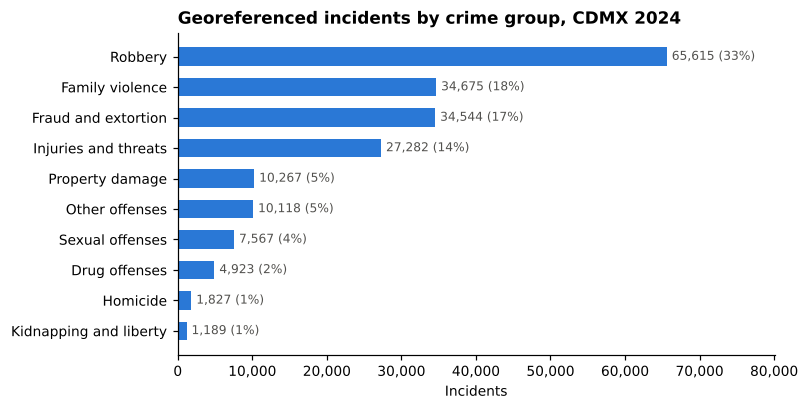

In [7]:
by_group = pd.read_sql("""
    SELECT ct.crime_category AS crime_group, COUNT(*) AS incidents
    FROM dw.fact_crime_incident c JOIN dw.dim_crime_type ct USING (crime_type_key)
    GROUP BY ct.crime_category ORDER BY incidents DESC
""", engine)
by_group["share"] = by_group.incidents / by_group.incidents.sum()

fig, ax = plt.subplots(figsize=(7, 3.8))
d = by_group.iloc[::-1]
ax.barh(d.crime_group, d.incidents, color="#2a78d6", height=0.6)
for y, (n, s) in enumerate(zip(d.incidents, d.share)):
    ax.text(n + d.incidents.max() * 0.01, y, f"{n:,.0f} ({s:.0%})", va="center", fontsize=8, color=viz.INK_MUTED)
ax.set_xlim(0, d.incidents.max() * 1.22)
ax.set_title("Georeferenced incidents by crime group, CDMX 2024", loc="left", fontweight="bold", fontsize=11)
ax.set_xlabel("Incidents"); ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
fig.savefig(FIGS / "fig_crimes_by_group.png", bbox_inches="tight", facecolor="white")
by_group

Busiest hour: **12:00** (23,270 incidents); quietest: **04:00** (3,706).

,time_band,incidents,share
0,afternoon,69114,0.349
1,morning,55875,0.282
2,evening,47550,0.240
3,night,25298,0.128


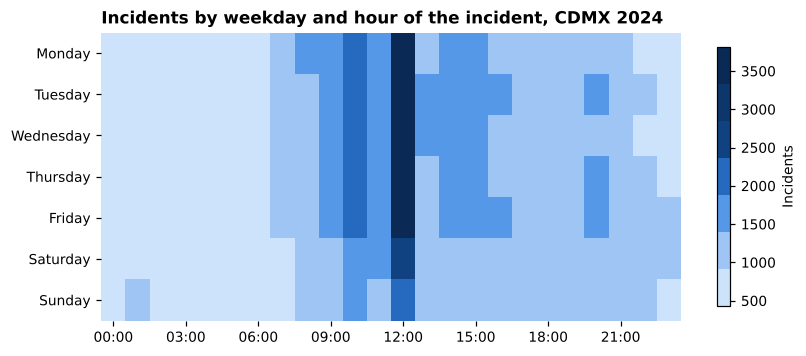

In [8]:
hw = pd.read_sql("""
    SELECT d.day_of_week, d.day_name, c.hour_key AS hour, COUNT(*) AS incidents
    FROM dw.fact_crime_incident c JOIN dw.dim_date d USING (date_key)
    WHERE c.hour_key IS NOT NULL
    GROUP BY d.day_of_week, d.day_name, c.hour_key
""", engine)
grid = hw.pivot(index="day_of_week", columns="hour", values="incidents").fillna(0)
days = hw.drop_duplicates("day_of_week").set_index("day_of_week").day_name.sort_index()

from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(figsize=(8.5, 3.4))
im = ax.imshow(grid.values, aspect="auto", cmap=ListedColormap(viz.BLUE_RAMP + ["#0a2a55"]))
ax.set_yticks(range(7)); ax.set_yticklabels(days.values)
ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)])
ax.set_title("Incidents by weekday and hour of the incident, CDMX 2024", loc="left", fontweight="bold", fontsize=11)
for s in ax.spines.values(): s.set_visible(False)
fig.colorbar(im, ax=ax, label="Incidents", shrink=0.9)
fig.savefig(FIGS / "fig_crimes_hour_weekday.png", bbox_inches="tight", facecolor="white")

peak = hw.groupby("hour").incidents.sum()
bands = pd.read_sql("""
    SELECT t.time_band, COUNT(*) AS incidents
    FROM dw.fact_crime_incident c JOIN dw.dim_time t ON t.hour_key = c.hour_key
    GROUP BY t.time_band ORDER BY incidents DESC
""", engine)
bands["share"] = bands.incidents / bands.incidents.sum()
display(Markdown(f"Busiest hour: **{peak.idxmax():02d}:00** ({peak.max():,.0f} incidents); quietest: **{peak.idxmin():02d}:00** ({peak.min():,.0f})."))
bands

In [9]:
import json
qa = json.loads((config.DOCS_QA / "crime_qa.json").read_text())
display(Markdown(
    f"**Data-quality note on the hour of the incident.** In the source file {qa['share_time_exactly_noon']:.1%} of reported times are "
    f"exactly 12:00 and {qa['share_time_on_round_hour']:.1%} fall on a round hour, so the noon band in the heatmap is largely a recording "
    "habit (unknown times default to noon, others are rounded) and not a real peak. Time-of-day results are therefore reported by "
    "broad time band, not by single hour. (Figures measured during cleaning, see `docs/qa/crime_qa.json`.)"))

**Data-quality note on the hour of the incident.** In the source file 8.3% of reported times are exactly 12:00 and 44.5% fall on a round hour, so the noon band in the heatmap is largely a recording habit (unknown times default to noon, others are rounded) and not a real peak. Time-of-day results are therefore reported by broad time band, not by single hour. (Figures measured during cleaning, see `docs/qa/crime_qa.json`.)

,month,month_name,incidents
0,1,January,16872
1,2,February,16807
2,3,March,17853
3,4,April,17724
4,5,May,18492
5,6,June,17097
6,7,July,16359
7,8,August,16672
8,9,September,15825
9,10,October,16012


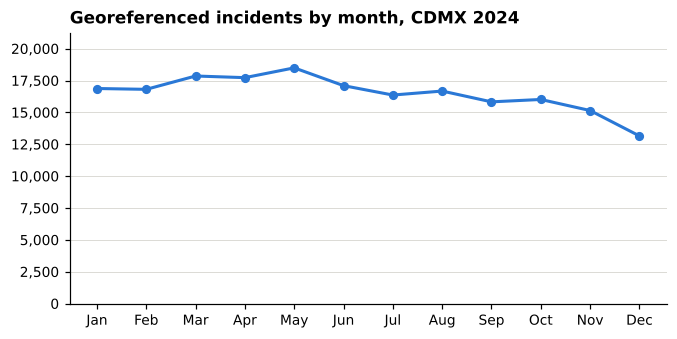

In [10]:
monthly = pd.read_sql("""
    SELECT d.month, d.month_name, COUNT(*) AS incidents
    FROM dw.fact_crime_incident c JOIN dw.dim_date d USING (date_key)
    GROUP BY d.month, d.month_name ORDER BY d.month
""", engine)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(monthly.month, monthly.incidents, color="#2a78d6", linewidth=2, marker="o", markersize=5)
ax.set_xticks(monthly.month); ax.set_xticklabels([m[:3] for m in monthly.month_name])
ax.set_ylim(0, monthly.incidents.max() * 1.15)
ax.set_title("Georeferenced incidents by month, CDMX 2024", loc="left", fontweight="bold", fontsize=11)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}"); ax.grid(axis="y", color=viz.GRID, linewidth=0.6)
fig.savefig(FIGS / "fig_crimes_by_month.png", bbox_inches="tight", facecolor="white")
monthly

The last months show fewer incidents. That is mostly registration lag in the source (cases are filed after the event), so the
December drop should not be read as a real fall in crime.

## 6. Alcaldia comparison

In [11]:
alc = (kpi.drop(columns="geometry").groupby("nom_mun")
       .agg(population=("total_population", "sum"), area_km2=("area_km2", "sum"),
            businesses=("total_businesses", "sum"), crimes=("total_crimes", "sum"), ageb=("cvegeo", "count")))
alc["pop_density_km2"] = alc.population / alc.area_km2
alc["businesses_per_1000"] = 1000 * alc.businesses / alc.population
alc["crimes_per_1000"] = 1000 * alc.crimes / alc.population
alc = alc.sort_values("crimes_per_1000", ascending=False)
alc.to_csv(TABLES / "kpis_by_alcaldia.csv")
alc.round(1)

,population,area_km2,businesses,crimes,ageb,pop_density_km2,businesses_per_1000,crimes_per_1000
nom_mun,,,,,,,,
Cuauhtémoc,545884,32.500,67389,28795,153,"16,796.900",123.400,52.700
Benito Juárez,434153,26.700,24135,15536,102,"16,272.600",55.600,35.800
Miguel Hidalgo,414470,46.400,25148,12071,130,"8,934.900",60.700,29.100
Venustiano Carranza,443704,33.800,29057,11723,151,"13,113.200",65.500,26.400
Coyoacán,614447,53.900,25079,14522,156,"11,404.000",40.800,23.600
Iztacalco,404695,23.100,17251,9410,110,"17,536.700",42.600,23.300
Azcapotzalco,432205,33.500,18774,8781,103,"12,903.000",43.400,20.300
Tlalpan,681501,93.700,25864,13458,207,"7,276.600",38.000,19.700
La Magdalena Contreras,246428,18.200,8285,4288,52,"13,518.700",33.600,17.400


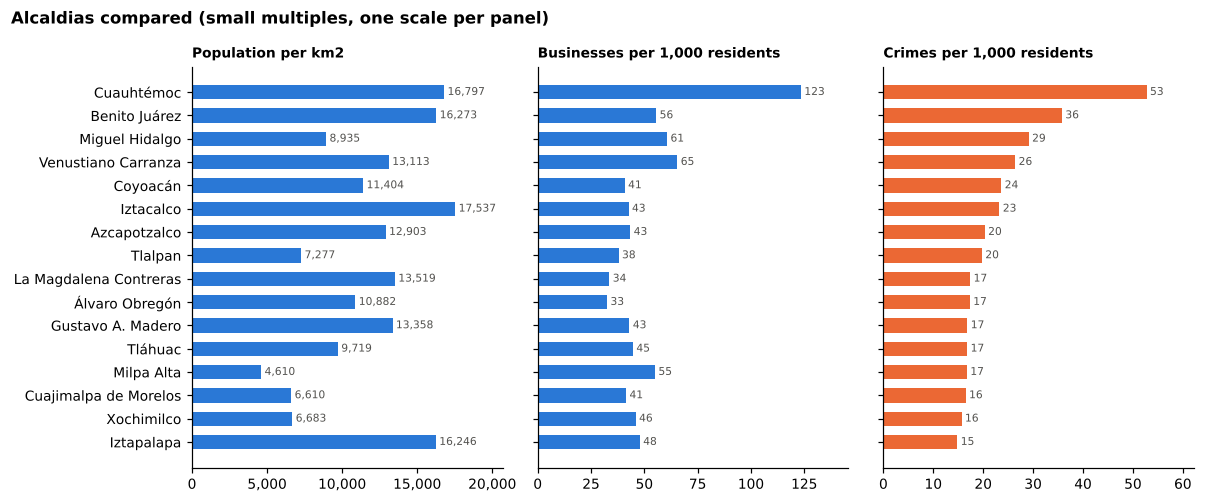

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.6), sharey=True)
order = alc.sort_values("crimes_per_1000").index
for ax, (col, title, color) in zip(axes, [("pop_density_km2", "Population per km2", "#2a78d6"),
                                          ("businesses_per_1000", "Businesses per 1,000 residents", "#2a78d6"),
                                          ("crimes_per_1000", "Crimes per 1,000 residents", "#eb6834")]):
    vals = alc.loc[order, col]
    ax.barh(order, vals, color=color, height=0.62)
    ax.set_title(title, loc="left", fontsize=9, fontweight="bold")
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    for y, v in enumerate(vals):
        ax.text(v, y, f" {v:,.0f}", va="center", fontsize=7, color=viz.INK_MUTED)
    ax.set_xlim(0, vals.max() * 1.18)
fig.suptitle("Alcaldias compared (small multiples, one scale per panel)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGS / "fig_alcaldia_summary.png", bbox_inches="tight", facecolor="white")

**Caution on per-resident crime rates.** Central alcaldias (Cuauhtemoc, Benito Juarez, Miguel Hidalgo) receive many commuters and
visitors who are not in the Census population, so their rate per resident is inflated compared with residential alcaldias.

## 7. Maps of the main indicators

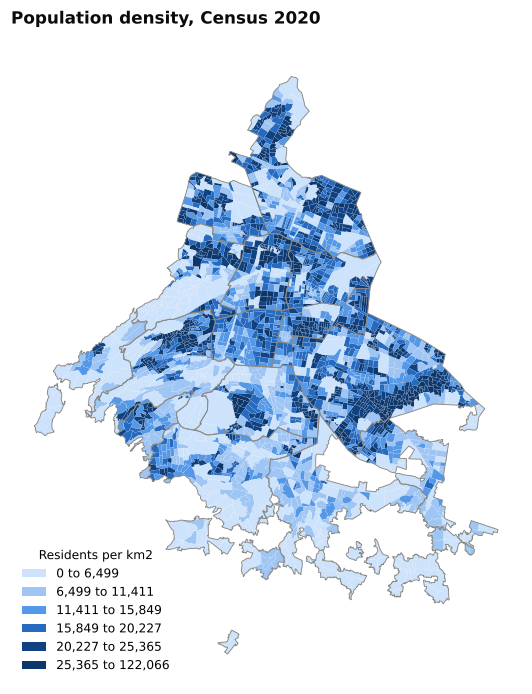

In [13]:
alcaldias = kpi.dissolve(by="cve_mun")[["geometry"]]
viz.choropleth(kpi, "population_density_km2", "Population density, Census 2020", viz.BLUE_RAMP,
               path=MAPS / "map_population_density.png", boundaries=alcaldias,
               legend_title="Residents per km2")
plt.show()

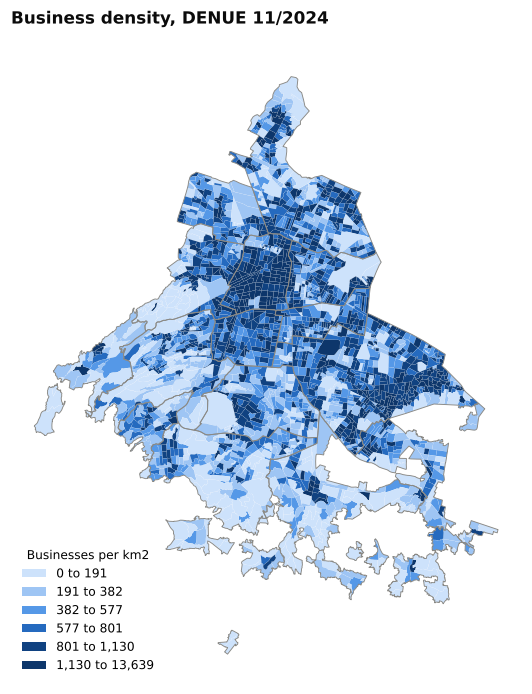

In [14]:
viz.choropleth(kpi, "business_density_km2", "Business density, DENUE 11/2024", viz.BLUE_RAMP,
               path=MAPS / "map_business_density.png", boundaries=alcaldias,
               legend_title="Businesses per km2")
plt.show()

Map shows 2,311 AGEB with at least 500 residents; 120 AGEB with fewer residents are left blank because their rates are unstable.

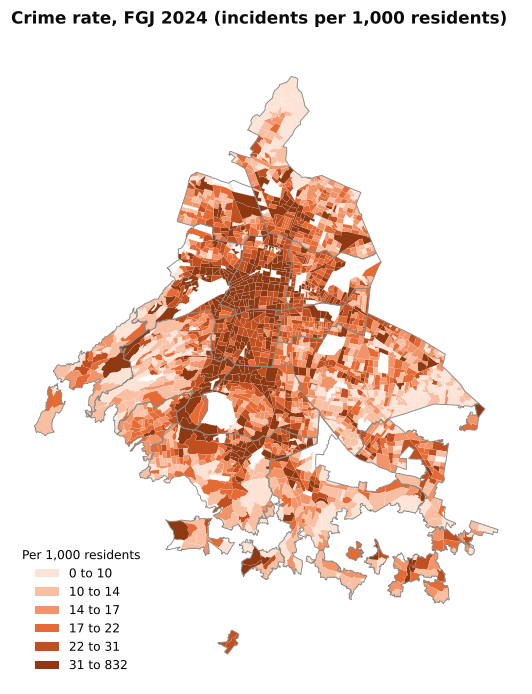

In [15]:
stable = sa.analysis_sample(kpi)   # AGEB with at least 500 residents so per-resident rates are stable
excluded = len(kpi) - len(stable)
viz.choropleth(stable, "crime_rate_per_1000", "Crime rate, FGJ 2024 (incidents per 1,000 residents)",
               viz.ORANGE_RAMP, path=MAPS / "map_crime_rate.png", boundaries=alcaldias,
               legend_title="Per 1,000 residents", fmt="{:,.0f}")
display(Markdown(f"Map shows {len(stable):,} AGEB with at least {sa.MIN_POP_FOR_RATES} residents; "
                 f"{excluded} AGEB with fewer residents are left blank because their rates are unstable."))
plt.show()

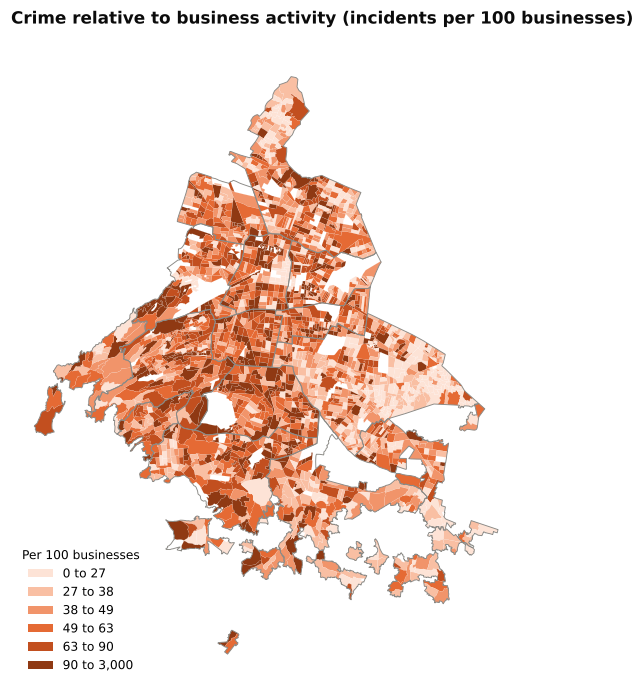

In [16]:
viz.choropleth(stable, "crimes_per_100_businesses", "Crime relative to business activity (incidents per 100 businesses)",
               viz.ORANGE_RAMP, path=MAPS / "map_crimes_per_business.png", boundaries=alcaldias,
               legend_title="Per 100 businesses", fmt="{:,.0f}")
plt.show()

## 8. Export the analytical table (generated from the warehouse)

In [17]:
export = kpi.drop(columns="geometry").sort_values("cvegeo")
export.to_csv(TABLES / "kpis_by_ageb.csv", index=False)
print(f"{len(export):,} rows x {export.shape[1]} columns written to outputs/tables/kpis_by_ageb.csv")

2,431 rows x 28 columns written to outputs/tables/kpis_by_ageb.csv
